### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go
from scipy.interpolate import interp1d
from scipy import integrate
import scipy.sparse as sp
import scipy.sparse.linalg as spla

### Input data:

In [2]:
mp = 179.7      #  (submerged pipe weight) [kg/m]
N = 15     # number of modelling nodes

In [3]:
qw = 1025 # Water density [kg/m3]
d0 = 0.508 # Outer diameter of pipe, [m]
dI= (508-33*2)/1000 # Inner diameter of pipe, [m]

In [4]:
# Underwater current: 
dv1_curr = 0
dv2_curr = 0
dv3_curr = 0

In [5]:
Fx_0 = 1515*1000
Fy_0 = 0.8*Fx_0
LTD = 209

In [6]:
E = 207e9
G = 79.3e9
nu0 = 0.3

In [7]:
TPL = 1_500

In [8]:
# vessel

In [9]:
mn = 39_989_000 # mass of the vessel, [kg]
L = 168 
Xg = 78 # [m]
Yg = 10
Zg = 1

In [10]:
# Fossen book p.181
def vessel_inertia_moment(mn, Xg, L):
    r = 0.25*L
    Ir = mn*r**2
    Iz = mn*Xg**2 + Ir
    return Iz

In [11]:
In = vessel_inertia_moment(mn, Xg, L)

In [12]:
draft = 6

In [13]:
# integration parameters
tspan = (0.,1e-04)

In [14]:
A_wp = 6000

In [15]:
damping_factor = 1

In [16]:
kp=1.5e10
kd=2.5e10

### Main functions:

In [17]:
A = np.pi * ((d0/2)**2 - (dI/2)**2)

In [18]:
m = (dI/2)/ (d0/2)
m2 = m**2
k_shear = (6.0 * (1.0 + nu0) * (1.0 + m2)**2) / (
    (7.0 + 6.0 * nu0) * (1.0 + m2)**2 + (20.0 + 12.0 * nu0) * m2)

In [19]:
A2 = k_shear * A
A3 = k_shear * A

In [20]:
J = (np.pi / 2.0) * ((d0/2)**4 - (dI/2)**4)

In [21]:
J1 = J

In [22]:
J2 = (np.pi / 64) * (d0**4 - dI**4)
J3 = J2

In [23]:
I1=(1/2)*mp*((d0/2)**2+(dI/2)**2)*TPL

In [24]:
I2 = (1/12)*mp*(3*(d0/2)**2+3*(dI/2)**2)*TPL
I3 = I2

In [25]:
def Πe(sφ,cφ,sθ,cθ,sψ,cψ):
    return np.array([
        [ cθ, 0, cφ * sθ], 
        [  0, 1, -sφ], 
        [-sθ, 0, cφ * cθ]
    ])    

In [26]:
def Ret_e_t(sφ,cφ,sθ,cθ,sψ,cψ):
    Cφ=np.array([[1,0,0],
                  [0,cφ,-sφ],
                  [0,sφ,cφ]])

    Cθ=np.array([[cθ,0,sθ],
                  [0,1,0],
                  [-sθ,0,cθ]])

    Cψ=np.array([[cψ,-sψ,0],
                  [sψ,cψ,0],
                  [0,0,1]])

    return Cθ @ Cφ @ Cψ    

In [27]:
diag_J_t_rho = np.array([J1, J2, J3])      
J_t_rho = np.diag(diag_J_t_rho)

In [28]:
diag_CT = np.array([E*A, G*A2, G*A3])
CT=np.diag(diag_CT)

In [29]:
diag_CR = np.array([G*J, E*J2, E*J3]) 
CR=np.diag(diag_CR) 

In [30]:
diag_DT = 1.5*np.array([1, 1, 1])
DT=np.diag(diag_DT)*damping_factor

In [31]:
diag_DR = 1.5*np.array([1, 1, 1])  
DR=np.diag(diag_DR)*damping_factor

In [32]:
def I_e_rho(RET):
    return RET @ J_t_rho @ RET.T

In [33]:
def phi(x,y,z): return np.array([x,y,z]) 
def theta(φ,θ,ψ): return np.array([φ,θ,ψ]) 

In [34]:
def d_s_theta(φ1,θ1,ψ1,φ2,θ2,ψ2,h):
    return 1/h*(theta(φ2,θ2,ψ2) - theta(φ1,θ1,ψ1))      

In [35]:
def S(a1, a2, a3 ):
    return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])

In [36]:
def d_s_phi(x1,y1,z1,x2,y2,z2, h):
    return 1/h*(phi(x2,y2,z2)-phi(x1,y1,z1))

In [37]:
def ne(x1, y1, z1, x2, y2, z2, RET, h):
    res = RET @ CT @ RET.T @ (
        d_s_phi(x1,y1,z1,x2,y2,z2,h).flatten() 
        - RET @ np.array([1,0,0])
    )
    return res.flatten()    

In [38]:
def me(φ1, θ1, ψ1, φ2, θ2, ψ2, RET, sφ,cφ,sθ,cθ,sψ,cψ, h):
    kappa_e = Πe(sφ,cφ,sθ,cθ,sψ,cψ) @ d_s_theta(φ1, θ1, ψ1, φ2, θ2, ψ2, h)
    return RET @ CR @ kappa_e   

In [39]:
def dΠ(sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ):
   
    return np.array([
        [-sθ*dθ, 0, -sφ*dφ*sθ + cφ*cθ*dθ],
        [  0, 0, -cφ*dφ],
        [-cθ*dθ, 0, -sφ*dφ*cθ - cφ*sθ*dθ]
    ])

In [40]:
fe_g = np.array([0,0, mp*TPL*9.81])

In [41]:
def f_t_d(dx,dy,dz): 
    
    vr1 = dx - dv1_curr
    vr2 = dy - dv2_curr  
    vr3 = dz - dv3_curr
    A = np.array([np.abs(vr1) * vr1,
                  np.sqrt(vr2**2 + vr3**2) * vr2,
                 np.sqrt(vr2**2 + vr3**2) * vr3])
    return 0.5 * d0 * qw * (DT@ A)

In [42]:
def sigma(x,y,z):
    e3 = np.array([0,0,1])
    
    k = - phi(x,y,z) @ e3+d0/2
    
    fe_g2 = np.linalg.norm(fe_g, ord=2)
   
    if k<0:
        k0=0
    elif 0<=k<=d0/20:
        k0=(fe_g2*10*k**2)/((d0/8-d0/40)*(d0))
    else:
        k0=(fe_g2*(k-d0/40))/(d0/8-d0/40)
            
    result = k0 * e3 
   
    return result  

In [43]:
def Hmtrx(r):
    r = np.asarray(r, dtype=float).flatten()
    H = np.eye(6)
    H[0:3, 3:6] = S(*r).T
    return H

In [44]:
def compute_damping(M_CG, G_CG, rCG, T_x, T_y, T_n):
 
    beta_z = 0.995      
    beta_phi = 0.995    
    beta_theta = 0.995
 
   
    zeta_z = np.sqrt(1 - beta_z ** 2)
    zeta_phi = np.sqrt(1 - beta_phi ** 2)
    zeta_theta = np.sqrt(1 - beta_theta ** 2)
 
    D_CG11 = M_CG[0, 0] / T_x
    D_CG22 = M_CG[1, 1] / T_y
    D_CG66 = M_CG[5, 5] / T_n
 
   
    k_z = G_CG[2, 2] if G_CG.ndim == 2 else G_CG[2]
    k_phi = G_CG[3, 3] if G_CG.ndim == 2 else G_CG[3]
    k_theta = G_CG[4, 4] if G_CG.ndim == 2 else G_CG[4]

    D_CG33 = 2 * zeta_z * np.sqrt(np.abs(M_CG[2, 2] * k_z))
    D_CG44 = 2 * zeta_phi * np.sqrt(np.abs(M_CG[3, 3] * k_phi))
    D_CG55 = 2 * zeta_theta * np.sqrt(np.abs(M_CG[4, 4] * k_theta))
 
    D_CG = np.diag([D_CG11, D_CG22, D_CG33, D_CG44, D_CG55, D_CG66])
 
    H = Hmtrx(rCG)
    D = H.T @ D_CG @ H
 
    return D

In [45]:
def compute_added_mass_placeholder(MRB_CG, rCG, ratios=None):
    """
    Reasonable stand-in for MA when you don't yet have geometry data to run
    `compute_added_mass`, but need a plausible, positive-definite MA to
    exercise the rest of the pipeline (M, G_CG, D, eigenvalues, periods).
 
    Rather than scaling the whole MRB matrix by one constant (e.g.
    MA = 0.5*MRB), this scales each diagonal DOF of MRB_CG by a *different*,
    physically motivated ratio, since added mass/inertia does not scale
    uniformly across DOFs. Typical literature ratios for semi-submersibles/
    ships (added mass or added inertia, as a fraction of rigid-body mass or
    inertia) are used as defaults:
 
        surge : 0.10   (slender-body, low added mass fore-aft)
        sway  : 0.80   (broadside added mass is large)
        heave : 1.20   (column-stabilized units: often exceeds rigid mass)
        roll  : 0.30   (added inertia, moderate)
        pitch : 0.90   (added inertia, large - long waterline)
        yaw   : 0.90   (added inertia, large)
 
    These are ROUGH DEFAULTS ONLY -- real added mass depends on hull/column/
    pontoon shape, submergence, and frequency, and should eventually be
    replaced by `compute_added_mass` once geometry data is available.
 
    Parameters
    ----------
    MRB_CG : (6, 6) ndarray
        Rigid-body mass matrix at CG (block-diagonal: m*I3, diag(Ix,Iy,Iz)).
    rCG : (3,) array_like
        Center of gravity with respect to CO (for the CG -> CO transform).
    ratios : (6,) array_like, optional
        Override the six default ratios above, in DOF order
        [surge, sway, heave, roll, pitch, yaw].
 
    Returns
    -------
    MA : (6, 6) ndarray
        Added mass matrix with respect to CO (diagonal at CG, transformed
        to CO -- no cross-coupling terms, unlike a geometry-derived MA).
    """
 
    if ratios is None:
        ratios = [0.10, 0.80, 1.20, 0.30, 0.90, 0.90]
 
    diag_CG = np.diag(MRB_CG)
    MA_CG = np.diag(diag_CG * np.asarray(ratios, dtype=float))
 
    # Transform from CG to CO -- same pattern used for MRB_CG -> MRB
    # elsewhere in this script: X_CO = Hmtrx(rCG).T @ X_CG @ Hmtrx(rCG)
    MA = Hmtrx(rCG).T @ MA_CG @ Hmtrx(rCG)
 
    return MA

In [46]:
def coriolis_matrix(M, nu):
    U = np.linalg.norm(nu)
    L = np.zeros((6, 6))
    L[1, 5] = 1.0  
    L[2, 4] = -1.0 
    C = M @ (U * L)
    return C

In [47]:
e1 = np.array([1.0, 0.0, 0.0])
e2 = np.array([0.0, 1.0, 0.0])
e3 = np.array([0.0, 0.0, 1.0])

In [48]:
class VesselRestoringParams:
    """
    Physical/geometric parameters needed for the restoring
    force/moment model, eqs. (57)-(63).
    """
    def __init__(self, A_wp, rho_w, g, z_eq, m_V, GM_L, GM_T):
        self.A_wp = A_wp      # water plane area [m^2]
        self.rho_w = rho_w    # water density [kg/m^3]
        self.g = g            # gravitational acceleration [m/s^2]
        self.z_eq = z_eq      # heave equilibrium position [m]
        self.m_V = m_V        # vessel mass [kg]
        self.GM_L = GM_L      # longitudinal metacentric height [m]
        self.GM_T = GM_T      # transversal metacentric height [m]

In [49]:
def heave_restoring_force(u_L, params: VesselRestoringParams):
    """
    g^e_l = -A_wp * rho_w * g * (u^T(L,t) e3 - z_eq) * e3

    Parameters
    ----------
    u_L : (3,) array
        Position of the pipe end attached to the vessel, u(L, t),
        expressed in the earth-fixed frame e.
    """
    heave = u_L @ e3
    g_e_l = -params.A_wp * params.rho_w * params.g * (heave - params.z_eq) * e3
    return g_e_l

In [50]:
def roll_pitch_sines(R_e_b):
    """
    sin(theta) and sin(phi) without explicit Euler angles, eqs. (59)-(60):
        sin(theta) = (R^e_b e1)^T e3
        sin(phi)  ~= (R^e_b e2)^T e3     (small-pitch approximation, cos(theta)=1)
    """
    sin_theta = (R_e_b @ e1) @ e3
    sin_phi = (R_e_b @ e2) @ e3
    return sin_phi, sin_theta

In [51]:
def moment_arm_body(R_e_b, params: VesselRestoringParams):
    """
    r~^b_r, eq. (61):
        r~^b_r = [ GM_L * (R^e_b e1)^T e3 ,
                   GM_T * (R^e_b e2)^T e3 ,
                   0 ]^T
    """
    sin_phi, sin_theta = roll_pitch_sines(R_e_b)
    r_tilde_b_r = np.array([
        params.GM_L * sin_theta,
        params.GM_T * sin_phi,
        0.0
    ])
    return r_tilde_b_r

In [52]:
def restoring_moment(R_e_b, params: VesselRestoringParams):
    """
    g^e_r = r~^e_r x f^e_r = (R^e_b r~^b_r) x (m_V g e3)
    """
    r_tilde_b_r = moment_arm_body(R_e_b, params)
    r_tilde_e_r = R_e_b @ r_tilde_b_r
    f_e_r = params.m_V * params.g * e3
    g_e_r = np.cross(r_tilde_e_r, f_e_r)
    return g_e_r

In [53]:
def restoring_vector_body(u_L, R_e_b, params: VesselRestoringParams):
    """
    g^b(u(L,t), R^e_b(t)) =
        [ (R^e_b)^T g^e_t ]
        [ (R^e_b)^T g^e_r ]

    where g^e_t = g^e_l (only heave translational restoring, eq. 57)
    and   g^e_r is the restoring moment, eq. (62).

    Returns
    -------
    g_b : (6,) ndarray
        [Fx, Fy, Fz, Mx, My, Mz] restoring generalized force in body frame.
    """
    g_e_t = heave_restoring_force(u_L, params)      # translational restoring, e-frame
    g_e_r = restoring_moment(R_e_b, params)          # rotational restoring, e-frame

    g_b_t = R_e_b.T @ g_e_t
    g_b_r = R_e_b.T @ g_e_r

    g_b = np.concatenate([g_b_t, g_b_r])
    return g_b

In [54]:
class MyTime:
    def __init__(self):
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.top_tension = 0
        self.sagbend_strain = 0
        self.my_iter = 0
        
        self.r_g = np.array([Xg, Yg, Zg])
        self.r_b = np.array([0, 0, -draft/2])
        
        self.W = mn*9.81
        self.BO = self.W
        
        self.MRB = np.block([[mn*np.identity(3), np.zeros((3,3))], 
                             [np.zeros((3,3)), In*np.identity(3)]])
        
        self.MA = compute_added_mass_placeholder(self.MRB, self.r_g)
        
        self.M = self.MRB + self.MA

        self.CRB = coriolis_matrix
        
        self.CA = coriolis_matrix

### Static solution

In [55]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

In [56]:
mi = [mp for i in range(N)]

In [57]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  # 113.07 - not submerged

In [58]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [59]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [60]:
delta_x=horizontal_length/(N-1)

In [61]:
x0=[i*delta_x for i in range(N)]
z0=[]

for i in range(len(x0)):
    z0.append(catenary(x0[i],Ws[0],Fx_0))

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [62]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

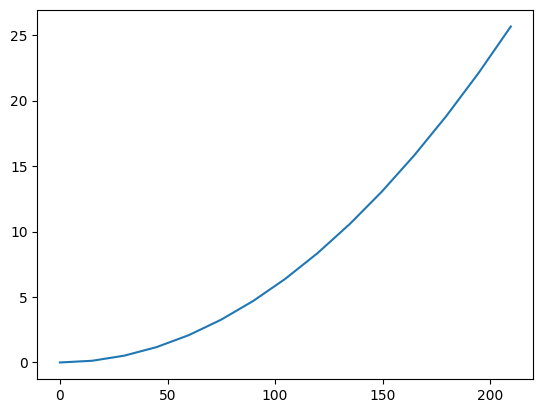

In [63]:
plt.plot(x0, z0)
plt.show()

In [64]:
q0=np.zeros(12*N)

In [65]:
for j in range(1,12):
    if j==1:
        q0[(j-1)*N:j*N]=x0
    elif j==5:
        q0[(j-1)*N:j*N]=z0

In [66]:
h = delta_x

In [67]:
def fun1(x_int, sφ,cφ,sθ,cθ,sψ,cψ, RET):
    
    def fun1_(x_int, sφ,cφ,sθ,cθ,sψ,cψ, RET):
        A=mp*TPL*1/2*(1-x_int)*1/2*(1+x_int)*np.identity(3)
        B=np.zeros((3,3))
        
        D=1/2*(1-x_int)*1/2*(1+x_int)*I_e_rho(RET)@Πe(sφ,cφ,sθ,cθ,sψ,cψ)
            
        return h/2*np.block([[A, B], [B, D]])
    
    res = np.array([fun1_(xi, sφ,cφ,sθ,cθ,sψ,cψ, RET) for xi in x_int])
    return np.moveaxis(res, 0, -1)


def fun2_1(x_int, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, RET,sφ,cφ,sθ,cθ,sψ,cψ, h):
    
    def fun2_1_(x_int, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2,RET,sφ,cφ,sθ,cθ,sψ,cψ, h):
        A=1/h*np.identity(3)
        B=np.zeros((3,3))
        C=-1/2*(1+x_int)*S(*d_s_phi(x1, y1, z1, x2, y2, z2, h))
        return h/2*np.block([[A, B], [C, A]])@np.concatenate((np.asarray(ne(x1, y1, z1, x2, y2, z2, RET, h)),
                                                              np.asarray(me(φ1, θ1, ψ1, φ2, θ2, ψ2, RET,sφ,cφ,sθ,cθ,sψ,cψ, h))), axis=None)
    
    res = np.array([fun2_1_(xi, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, RET,sφ,cφ,sθ,cθ,sψ,cψ, h) for xi in x_int])
    return np.moveaxis(res, 0, -1)

    
def fun2_2(x_int, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, RET,sφ,cφ,sθ,cθ,sψ,cψ, h):
    
    def fun2_2_(x_int, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, RET,sφ,cφ,sθ,cθ,sψ,cψ, h):
        A=1/h*np.identity(3)
        B=np.zeros((3,3))
        C=-1/2*(1-x_int)*S(*d_s_phi(x1, y1, z1, x2, y2, z2, h))
        return h/2*np.block([[A, B], [C, A]])@np.concatenate((np.asarray(ne(x1, y1, z1, x2, y2, z2, RET, h)),
                                                              np.asarray(me(φ1, θ1, ψ1, φ2, θ2, ψ2, RET,sφ,cφ,sθ,cθ,sψ,cψ, h))), axis=None)
    
    res = np.array([fun2_2_(xi, x1, y1, z1, φ1, θ1, ψ1, x2, y2, z2, φ2, θ2, ψ2, RET, sφ,cφ,sθ,cθ,sψ,cψ, h) for xi in x_int])
    return np.moveaxis(res, 0, -1)    

    
def fun3_1(x_int,sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ, RET):
    
    def fun3_1_(x_int,sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ, RET):
        A=np.zeros(3)
          
        B=1/2*(1+x_int)*I_e_rho(RET)@dΠ(sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ)@np.array([dφ, dθ, dψ])
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun3_1_(xi,sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ, RET) for xi in x_int])
    return np.moveaxis(res, 0, -1)  

    
def fun3_2(x_int,sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ,RET):
    
    def fun3_2_(x_int,sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ,RET):
        A=np.zeros(3)
          
        B=1/2*(1-x_int)*I_e_rho(RET)@dΠ(sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ)@np.array([dφ, dθ, dψ])
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun3_2_(xi,sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ, RET) for xi in x_int])
    return np.moveaxis(res, 0, -1)    

    
def fun4_1(x_int,sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ,RET):
    
    def fun4_1_(x_int,sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ,RET):
        A=np.zeros(3)
            
        B=1/2*(1+x_int)*S(*(Πe(sφ,cφ,sθ,cθ,sψ,cψ)@np.array([dφ, dθ, dψ])))@(I_e_rho(RET)@Πe(sφ,cφ,sθ,cθ,sψ,cψ)@np.array([dφ, dθ, dψ])).T
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun4_1_(xi,sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ,RET) for xi in x_int])
    return np.moveaxis(res, 0, -1)

    
def fun4_2(x_int,sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ,RET):
    
    def fun4_2_(x_int,sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ,RET):
        A=np.zeros(3) 
       
        B=1/2*(1-x_int)*S(*(Πe(sφ,cφ,sθ,cθ,sψ,cψ)@np.array([dφ, dθ, dψ])))@(I_e_rho(RET)@Πe(sφ,cφ,sθ,cθ,sψ,cψ)@np.array([dφ, dθ, dψ])).T
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun4_2_(xi,sφ,cφ,sθ,cθ,sψ,cψ, dφ, dθ, dψ, RET) for xi in x_int])
    return np.moveaxis(res, 0, -1)    

    
def fun5_1(x_int, li):
    
    def fun5_1_(x_int, li):
        B=np.zeros(3)   
        A=1/2*(1+x_int)*fe_g*li
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun5_1_(x, li) for x in x_int])
    return np.moveaxis(res, 0, -1)

    
def fun5_2(x_int, li):
    
    def fun5_2_(x_int, li):
        B=np.zeros(3)   
        A=1/2*(1-x_int)*fe_g*li
        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun5_2_(x, li) for x in x_int])
    return np.moveaxis(res, 0, -1)    

    
def fun6_1(x_int,sφ,cφ,sθ,cθ,sψ,cψ, dx, dy, dz, dφ, dθ, dψ, RET):
    
    def fun6_1_(x_int,sφ,cφ,sθ,cθ,sψ,cψ, dx, dy, dz, dφ, dθ, dψ,RET):
        A=1/2*(1+x_int)* RET@f_t_d(dx,dy,dz)
        B=1/2*(1+x_int)* DR@ Πe(sφ,cφ,sθ,cθ,sψ,cψ)@  np.array([dφ, dθ, dψ])

        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)  
    
    res = np.array([fun6_1_(xi,sφ,cφ,sθ,cθ,sψ,cψ, dx, dy, dz, dφ, dθ, dψ, RET) for xi in x_int])
    return np.moveaxis(res, 0, -1)


def fun6_2(x_int,sφ,cφ,sθ,cθ,sψ,cψ, dx, dy, dz, dφ, dθ, dψ,RET):
    
    def fun6_2_(x_int,sφ,cφ,sθ,cθ,sψ,cψ, dx, dy, dz, dφ, dθ, dψ,RET):
        A=1/2*(1-x_int)* RET@f_t_d(dx,dy,dz)
        B=1/2*(1-x_int)* DR@ Πe(sφ,cφ,sθ,cθ,sψ,cψ)@  np.array([dφ, dθ, dψ])

        return h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)
    
    res = np.array([fun6_2_(xi,sφ,cφ,sθ,cθ,sψ,cψ, dx, dy, dz, dφ, dθ, dψ, RET) for xi in x_int])
    return np.moveaxis(res, 0, -1)    

    
def fun7_1(x_int,x,y,z):
   
    def fun7_1_(x_int,x,y,z):
        A=1/2*(1+x_int)*sigma(x,y,z)
        B=np.zeros(3) 

        ans=h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)

        return ans
    
    res = np.array([fun7_1_(xi,x,y,z) for xi in x_int])
    return np.moveaxis(res, 0, -1)


def fun7_2(x_int,x,y,z):
   
    def fun7_2_(x_int,x,y,z):
        A=1/2*(1-x_int)*sigma(x,y,z)
        B=np.zeros(3) 

        ans=h/2*np.concatenate((np.asarray(A), np.asarray(B)), axis=None)

        return ans
    
    res = np.array([fun7_2_(xi,x,y,z) for xi in x_int])
    return np.moveaxis(res, 0, -1)    

In [68]:
def body_frame_nu(u_dot_xyz, sφ,cφ,sθ,cθ,sψ,cψ,  dphi, dtheta, dpsi, RET):
    """Eq. (64): rotate spatial velocity + convert Euler rates -> body-frame nu."""
    Re_b = RET
    w_e  = Πe(sφ,cφ,sθ,cθ,sψ,cψ) @ np.array([dphi, dtheta, dpsi])   # Eq. (100)
    nu_lin = Re_b.T @ np.asarray(u_dot_xyz)
    nu_ang = Re_b.T @ w_e
    return np.concatenate([nu_lin, nu_ang])

In [69]:
def static_solution(Q,T): 
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    sφ,cφ,sθ,cθ,sψ,cψ=Q[12*N:13*N],Q[13*N:14*N],Q[14*N:15*N],Q[15*N:16*N],Q[16*N:17*N],Q[17*N:18*N]

    k = 18*N

    R11 = Q[k+0*N:k+1*N]
    R12 = Q[k+1*N:k+2*N]
    R13 = Q[k+2*N:k+3*N]

    R21 = Q[k+3*N:k+4*N]
    R22 = Q[k+4*N:k+5*N]
    R23 = Q[k+5*N:k+6*N]

    R31 = Q[k+6*N:k+7*N]
    R32 = Q[k+7*N:k+8*N]
    R33 = Q[k+8*N:k+9*N]
    
  
    
    f1=[]
    f2=[]
    f3=[] 
    f4=[]
    f5=[]
    f6=[]
    f7=[]
    f8=[]
   
    dsφ,dcφ,dsθ,dcθ,dsψ,dcψ=np.zeros(N),np.zeros(N),np.zeros(N),np.zeros(N),np.zeros(N),np.zeros(N)

    dR11 = np.zeros(N)
    dR12 = np.zeros(N)
    dR13 = np.zeros(N)

    dR21 = np.zeros(N)
    dR22 = np.zeros(N)
    dR23 = np.zeros(N)

    dR31 = np.zeros(N)
    dR32 = np.zeros(N)
    dR33 = np.zeros(N)
    
    for j in range(1, N):

        RET = np.array([
            [R11[j], R12[j], R13[j]],
            [R21[j], R22[j], R23[j]],
            [R31[j], R32[j], R33[j]]
        ])

        omega_e = Πe(
            sφ[j],cφ[j],
            sθ[j],cθ[j],
            sψ[j],cψ[j]
        ) @ np.array([
            dφ[j],
            dθ[j],
            dψ[j]
        ])

        dsφ[j],dcφ[j],dsθ[j],dcθ[j],dsψ[j],dcψ[j]=  dφ[j]*cφ[j],-dφ[j]*sφ[j],   dθ[j]*cθ[j],-dθ[j]*sθ[j],   dψ[j]*cψ[j], -dψ[j]*sψ[j]

        Omega = S(
            omega_e[0],
            omega_e[1],
            omega_e[2]
        )
        
        dRET = Omega @ RET

        dR11[j], dR12[j], dR13[j] = dRET[0,:]
        dR21[j], dR22[j], dR23[j] = dRET[1,:]
        dR31[j], dR32[j], dR33[j] = dRET[2,:]
        
        if j == N-1:
            g_eta = restoring_vector_body(phi(x[j],y[j],z[j]), RET, 
                                      VesselRestoringParams(
                                                            A_wp = A_wp,     # m^2, water plane area
                                                            rho_w = qw,    # kg/m^3
                                                            g = 9.81,       # m/s^2
                                                            z_eq = z0[-1],  # equilibrium heave [m]
                                                            m_V = mn,       # kg, vessel mass
                                                            GM_L = L,       # m, longitudinal metacentric height
                                                            GM_T = 2*Yg,        # m, transversal metacentric height
                                                        ))
            
            f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int, sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j], RET), -1.0, 1.0, n=2)[0])
            f2.append(integrate.fixed_quad(lambda x_int: fun2_1(x_int, x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j], RET,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j], h), -1.0,1.0,n=1)[0])
            f3.append(integrate.fixed_quad(lambda x_int: fun3_1(x_int, sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j],dφ[j],dθ[j],dψ[j],RET), -1.0, 1.0, n=2)[0])
            f4.append(integrate.fixed_quad(lambda x_int: fun4_1(x_int,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j],dφ[j],dθ[j],dψ[j],RET), -1.0, 1.0, n=2)[0])
            f5.append(integrate.fixed_quad(lambda x_int: fun5_1(x_int, 1), -1.0, 1.0, n=2)[0])
            f6.append(integrate.fixed_quad(lambda x_int: fun6_1(x_int,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j],RET), -1.0, 1.0, n=2)[0])
            f7.append(integrate.fixed_quad(lambda x_int: fun7_1(x_int, x[j],y[j],z[j]), -1.0, 1.0, n=2)[0])
            # f8.append(g_eta)
            f8.append(np.zeros(6))
        else:
            f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int, sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j], RET), -1.0, 1.0, n=2)[0])
            f2.append(integrate.fixed_quad(lambda x_int: fun2_1(x_int, x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j], RET,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j], h), -1.0,1.0,n=1)[0]
                     +integrate.fixed_quad(lambda x_int: fun2_2(x_int, x[j],y[j],z[j],φ[j],θ[j],ψ[j],x[j+1],y[j+1],z[j+1],φ[j+1],θ[j+1],ψ[j+1], RET,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j], h), -1.0,1.0,n=1)[0])
            f3.append(integrate.fixed_quad(lambda x_int: fun3_1(x_int,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j],dφ[j],dθ[j],dψ[j],RET), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun3_2(x_int,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j],dφ[j],dθ[j],dψ[j],RET), -1.0, 1.0, n=2)[0])
            f4.append(integrate.fixed_quad(lambda x_int: fun4_1(x_int,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j],dφ[j],dθ[j],dψ[j],RET), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun4_2(x_int,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j],dφ[j],dθ[j],dψ[j],RET), -1.0, 1.0, n=2)[0])
            f5.append(integrate.fixed_quad(lambda x_int: fun5_1(x_int, 1), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun5_2(x_int, 1), -1.0, 1.0, n=2)[0])
            f6.append(integrate.fixed_quad(lambda x_int: fun6_1(x_int,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j],RET), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun6_2(x_int,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j],RET), -1.0, 1.0, n=2)[0])
            f7.append(integrate.fixed_quad(lambda x_int: fun7_1(x_int, x[j],y[j],z[j]), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun7_2(x_int, x[j],y[j],z[j]), -1.0, 1.0, n=2)[0])
            f8.append(np.zeros(6))

    f1 = np.array(f1)
    f1 = np.stack(f1, axis=0)
    f2=np.vstack(f2) 
    f3=np.vstack(f3)
    f4=np.vstack(f4) 
    f5=np.vstack(f5)
    f6=np.vstack(f6) 
    f7=np.vstack(f7) 
    f8=np.vstack(f8)
    
    ddx=np.zeros(N)
    ddy=np.zeros(N)
    ddz=np.zeros(N)
    ddφ=np.zeros(N)
    ddθ=np.zeros(N)
    ddψ=np.zeros(N)
   
    
    
    f_sum = -(f2 + f3 + f4 + f5 + f6 + f8) 
    X = np.linalg.solve(f1, f_sum).reshape(N-1, 6)

    ddx0, ddy0, ddz0, ddφ0, ddθ0, ddψ0 = X.T  

    ddx[1:], ddy[1:], ddz[1:], ddφ[1:], ddθ[1:], ddψ[1:] = ddx0, ddy0, ddz0, ddφ0, ddθ0, ddψ0
      
    ans=np.concatenate([
        dx, ddx,
        dy, ddy,
        dz, ddz,
    
        dφ, ddφ,
        dθ, ddθ,
        dψ, ddψ,
    
        dsφ, dcφ,
        dsθ, dcθ,
        dsψ, dcψ,
    
        dR11, dR12, dR13,
        dR21, dR22, dR23,
        dR31, dR32, dR33
    ], axis=0)
  
    return ans

In [70]:
T_1 = MyTime()

In [71]:
R0 = np.zeros((N,3,3))

φ0 = q0[6*N:7*N]
θ0 = q0[8*N:9*N]
ψ0 = q0[10*N:11*N]

for j in range(N):
    sφ0 = np.sin(φ0[j])
    cφ0 = np.cos(φ0[j])

    sθ0 = np.sin(θ0[j])
    cθ0 = np.cos(θ0[j])

    sψ0 = np.sin(ψ0[j])
    cψ0 = np.cos(ψ0[j])

    R0[j] = Ret_e_t( sφ0,cφ0,sθ0,cθ0,sψ0,cψ0)

R11_0 = R0[:,0,0]
R12_0 = R0[:,0,1]
R13_0 = R0[:,0,2]

R21_0 = R0[:,1,0]
R22_0 = R0[:,1,1]
R23_0 = R0[:,1,2]

R31_0 = R0[:,2,0]
R32_0 = R0[:,2,1]
R33_0 = R0[:,2,2]    

In [72]:
cs0 = np.concatenate((np.zeros(N),np.ones(N),np.zeros(N),np.ones(N),np.zeros(N),np.ones(N)))

In [73]:
q0 = np.concatenate((q0,cs0,
                     R11_0, R12_0, R13_0,
                     R21_0, R22_0, R23_0,
                     R31_0, R32_0, R33_0))

In [74]:
root_ = root(static_solution, q0, 
             method='lm', 
             args=(T_1,))

In [75]:
root_

 message: The relative error between two consecutive iterates is at most 0.000000
 success: True
  status: 2
     fun: [ 6.511e-11  7.255e-11 ...  1.112e-19 -4.059e-04]
       x: [-1.425e+00  1.469e+01 ...  7.533e-01  7.700e-01]
   cov_x: None
  method: lm
    nfev: 8133
    fjac: [[-8.567e+21  0.000e+00 ...  0.000e+00  0.000e+00]
           [ 0.000e+00 -2.439e+21 ...  0.000e+00  0.000e+00]
           ...
           [ 0.000e+00  0.000e+00 ... -0.000e+00  0.000e+00]
           [ 0.000e+00  0.000e+00 ...  0.000e+00 -0.000e+00]]
    ipvt: [326 325 ... 211 301]
     qtf: [-2.537e+01  5.582e+00 ...  1.240e-17 -6.610e-17]

In [76]:
x0_, y0_, z0_ = root_.x[:N],root_.x[2*N:3*N], root_.x[4*N:5*N]

In [77]:
q0 = root_.x                                         # start from static solution

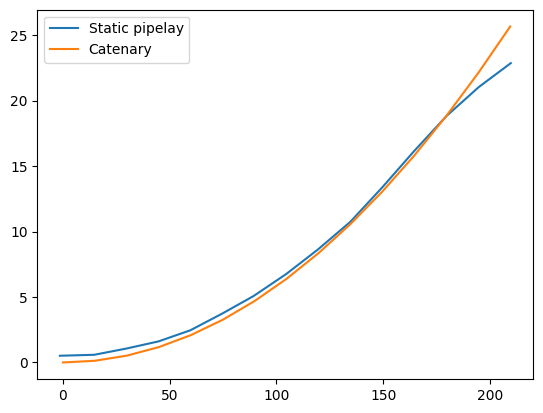

In [78]:
plt.plot(x0_, z0_, label = "Static pipelay")
plt.plot(x0, z0, label = "Catenary")
plt.legend()
plt.show()

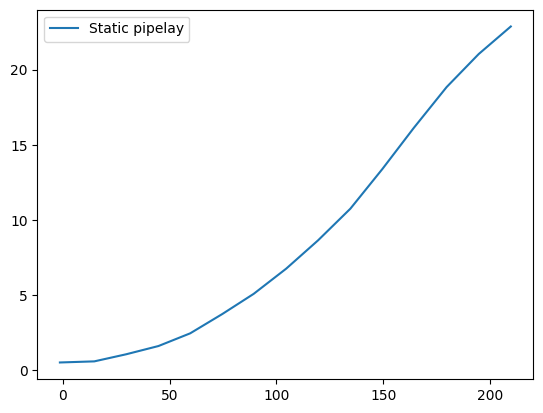

In [79]:
plt.plot(x0_, z0_, label = "Static pipelay")
plt.legend()
plt.show()

### Dynamic Simulation

In [80]:
def dynamic_func(t, Q, T):
        
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    sφ,cφ,sθ,cθ,sψ,cψ=Q[12*N:13*N],Q[13*N:14*N],Q[14*N:15*N],Q[15*N:16*N],Q[16*N:17*N],Q[17*N:18*N]

    k = 18*N

    R11 = Q[k+0*N:k+1*N]
    R12 = Q[k+1*N:k+2*N]
    R13 = Q[k+2*N:k+3*N]

    R21 = Q[k+3*N:k+4*N]
    R22 = Q[k+4*N:k+5*N]
    R23 = Q[k+5*N:k+6*N]

    R31 = Q[k+6*N:k+7*N]
    R32 = Q[k+7*N:k+8*N]
    R33 = Q[k+8*N:k+9*N]

    f1=[]
    f2=[]
    f3=[] 
    f4=[]
    f5=[]
    f6=[]
    f7=[]
    f8=[]


    dsφ,dcφ,dsθ,dcθ,dsψ,dcψ=np.zeros(N),np.zeros(N),np.zeros(N),np.zeros(N),np.zeros(N),np.zeros(N)

    dR11 = np.zeros(N)
    dR12 = np.zeros(N)
    dR13 = np.zeros(N)

    dR21 = np.zeros(N)
    dR22 = np.zeros(N)
    dR23 = np.zeros(N)

    dR31 = np.zeros(N)
    dR32 = np.zeros(N)
    dR33 = np.zeros(N)

    for j in range(1,N):

        RET = np.array([
            [R11[j], R12[j], R13[j]],
            [R21[j], R22[j], R23[j]],
            [R31[j], R32[j], R33[j]]
        ])

        omega_e = Πe(
            sφ[j],cφ[j],
            sθ[j],cθ[j],
            sψ[j],cψ[j]
        ) @ np.array([
            dφ[j],
            dθ[j],
            dψ[j]
        ])

        dsφ[j],dcφ[j],dsθ[j],dcθ[j],dsψ[j],dcψ[j]=  dφ[j]*cφ[j],-dφ[j]*sφ[j],   dθ[j]*cθ[j],-dθ[j]*sθ[j],   dψ[j]*cψ[j], -dψ[j]*sψ[j]

        Omega = S(
            omega_e[0],
            omega_e[1],
            omega_e[2]
        )
        
        dRET = Omega @ RET

        dR11[j], dR12[j], dR13[j] = dRET[0,:]
        dR21[j], dR22[j], dR23[j] = dRET[1,:]
        dR31[j], dR32[j], dR33[j] = dRET[2,:]
        
        
        if j == N-1:
            nu = body_frame_nu(np.array([dx[j], dy[j], dz[j]]), sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j], dφ[j], dθ[j], dψ[j], RET)
            C_nu = T.CRB(T.MRB, nu) + T.CA(T.MA, nu)
            g_eta = restoring_vector_body(phi(x[j],y[j],z[j]), RET, 
                                      VesselRestoringParams(
                                                            A_wp = A_wp,     # m^2, water plane area
                                                            rho_w = qw,    # kg/m^3
                                                            g = 9.81,       # m/s^2
                                                            z_eq = z0_[-1],  # equilibrium heave [m]
                                                            m_V = mn,       # kg, vessel mass
                                                            GM_L = L,       # m, longitudinal metacentric height
                                                            GM_T = 2*Yg,        # m, transversal metacentric height
                                                        ))
    
            D_nu = compute_damping(T.MRB, g_eta, T.r_g, 20, 100, 50)
    
            for_nu = np.block([[RET,  np.zeros((3,3))], 
                             [np.zeros((3,3)),  RET @ Πe(sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j])]])
    
            f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int, sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j], RET), -1.0, 1.0, n=2)[0]
                      + T.M @ for_nu
                     )
            f2.append(integrate.fixed_quad(lambda x_int: fun2_1(x_int, x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j], RET,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j], h), -1.0,1.0,n=1)[0])
            f3.append(integrate.fixed_quad(lambda x_int: fun3_1(x_int, sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j],dφ[j],dθ[j],dψ[j],RET), -1.0, 1.0, n=2)[0])
            f4.append(integrate.fixed_quad(lambda x_int: fun4_1(x_int,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j],dφ[j],dθ[j],dψ[j],RET), -1.0, 1.0, n=2)[0])
            f5.append(integrate.fixed_quad(lambda x_int: fun5_1(x_int, 1), -1.0, 1.0, n=2)[0])
            f6.append(integrate.fixed_quad(lambda x_int: fun6_1(x_int,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j],RET), -1.0, 1.0, n=2)[0])
            f7.append(integrate.fixed_quad(lambda x_int: fun7_1(x_int, x[j],y[j],z[j]), -1.0, 1.0, n=2)[0])        
            # f8.append(g_eta  + (C_nu + D_nu) @ nu) 
            f8.append(g_eta  + (C_nu + D_nu) @ nu + kp*np.concatenate((phi(x[j],y[j],z[j]),theta(φ[j],θ[j],ψ[j]))) + kd*nu)
        else:
            f1.append(integrate.fixed_quad(lambda x_int: fun1(x_int, sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j], RET), -1.0, 1.0, n=2)[0])
            f2.append(integrate.fixed_quad(lambda x_int: fun2_1(x_int, x[j-1],y[j-1],z[j-1],φ[j-1],θ[j-1],ψ[j-1],x[j],y[j],z[j],φ[j],θ[j],ψ[j], RET,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j], h), -1.0,1.0,n=1)[0]
                     +integrate.fixed_quad(lambda x_int: fun2_2(x_int, x[j],y[j],z[j],φ[j],θ[j],ψ[j],x[j+1],y[j+1],z[j+1],φ[j+1],θ[j+1],ψ[j+1], RET,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j], h), -1.0,1.0,n=1)[0])
            f3.append(integrate.fixed_quad(lambda x_int: fun3_1(x_int,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j],dφ[j],dθ[j],dψ[j],RET), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun3_2(x_int,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j],dφ[j],dθ[j],dψ[j],RET), -1.0, 1.0, n=2)[0])
            f4.append(integrate.fixed_quad(lambda x_int: fun4_1(x_int,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j],dφ[j],dθ[j],dψ[j],RET), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun4_2(x_int,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j],dφ[j],dθ[j],dψ[j],RET), -1.0, 1.0, n=2)[0])
            f5.append(integrate.fixed_quad(lambda x_int: fun5_1(x_int, 1), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun5_2(x_int, 1), -1.0, 1.0, n=2)[0])
            f6.append(integrate.fixed_quad(lambda x_int: fun6_1(x_int,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j],RET), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun6_2(x_int,sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j],dx[j],dy[j],dz[j],dφ[j],dθ[j],dψ[j],RET), -1.0, 1.0, n=2)[0])
            f7.append(integrate.fixed_quad(lambda x_int: fun7_1(x_int, x[j],y[j],z[j]), -1.0, 1.0, n=2)[0]
                     +integrate.fixed_quad(lambda x_int: fun7_2(x_int, x[j],y[j],z[j]), -1.0, 1.0, n=2)[0])
            f8.append(np.zeros(6))
         
        if t>0.01 and j>0:
            ax = RET.T @ ne(x[j-1], y[j-1], z[j-1],x[j], y[j], z[j], RET, h).T

            T.top_tension=max(T.top_tension, ax[0])            
                                     
            ben0 = RET.T @ me(φ[j-1], θ[j-1], ψ[j-1], φ[j],θ[j],ψ[j], RET, sφ[j],cφ[j],sθ[j],cθ[j],sψ[j],cψ[j], h)
            ben=np.max(ben0[1:])

            I=3.14*(d0**4-dI**4)/64
            strain=np.max(ben)*d0/(2*E*I)    

            T.sagbend_strain=max(T.sagbend_strain, strain)    
    

    f1 = np.array(f1)
    f1 = np.stack(f1, axis=0)
    f2=np.vstack(f2) 
    f3=np.vstack(f3)
    f4=np.vstack(f4) 
    f5=np.vstack(f5)
    f6=np.vstack(f6) 
    f7=np.vstack(f7)
    f8=np.vstack(f8)
    
    ddx=np.zeros(N)
    ddy=np.zeros(N)
    ddz=np.zeros(N)
    ddφ=np.zeros(N)
    ddθ=np.zeros(N)
    ddψ=np.zeros(N)
    
    f_sum = -(f2 + f3 + f4 + f5 + f6  + f8) 
    
    X = np.linalg.solve(f1, f_sum).reshape(N-1, 6)

    ddx0, ddy0, ddz0, ddφ0, ddθ0, ddψ0 = X.T  

    ddx[1:], ddy[1:], ddz[1:], ddφ[1:], ddθ[1:], ddψ[1:] = ddx0, ddy0, ddz0, ddφ0, ddθ0, ddψ0

    ans=np.concatenate([
        dx, ddx,
        dy, ddy,
        dz, ddz,
    
        dφ, ddφ,
        dθ, ddθ,
        dψ, ddψ,
    
        dsφ, dcφ,
        dsθ, dcθ,
        dsψ, dcψ,
    
        dR11, dR12, dR13,
        dR21, dR22, dR23,
        dR31, dR32, dR33
    ], axis=0)
  


        
    if t>T.progression[0]:
        T.progression.pop(0)
        print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock , flush=True)
        T.wall_clock = datetime.now() 
    
    T.my_iter+=1 
    
    return ans

In [81]:
T_2 = MyTime()

In [82]:
startTime1 = datetime.now()
us_ = solve_ivp(dynamic_func, 
                tspan, 
                q0, 
                args=(T_2, ), 
                method='RK23', # 'BDF'
                max_step=0.01,
                rtol=1e-06, 
                atol=1e-09
               )
print(datetime.now() - startTime1)

Physical time:  1.860997661887216e-09  Iteration wall-clock time:  0:00:00.018604
0:06:14.850675


### Results

In [83]:
# number of iterations
T_2.my_iter

62639

In [84]:
# max axial tension
T_2.top_tension

0

In [85]:
# max bending strain
T_2.sagbend_strain

0

In [86]:
fin=us_

In [87]:
fin

  message: Required step size is less than spacing between numbers.
  success: False
   status: -1
        t: [ 0.000e+00  5.359e-11 ...  8.817e-05  8.817e-05]
        y: [[-1.425e+00 -1.425e+00 ... -1.425e+00 -1.425e+00]
            [ 1.469e+01  1.469e+01 ...  1.469e+01  1.469e+01]
            ...
            [ 7.533e-01  7.533e-01 ...  7.533e-01  7.533e-01]
            [ 7.700e-01  7.700e-01 ...  7.700e-01  7.700e-01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 62639
     njev: 0
      nlu: 0

In [88]:
t=fin.t

In [89]:
fin=fin.y.T

In [90]:
t.shape, fin.shape

((19363,), (19363, 405))

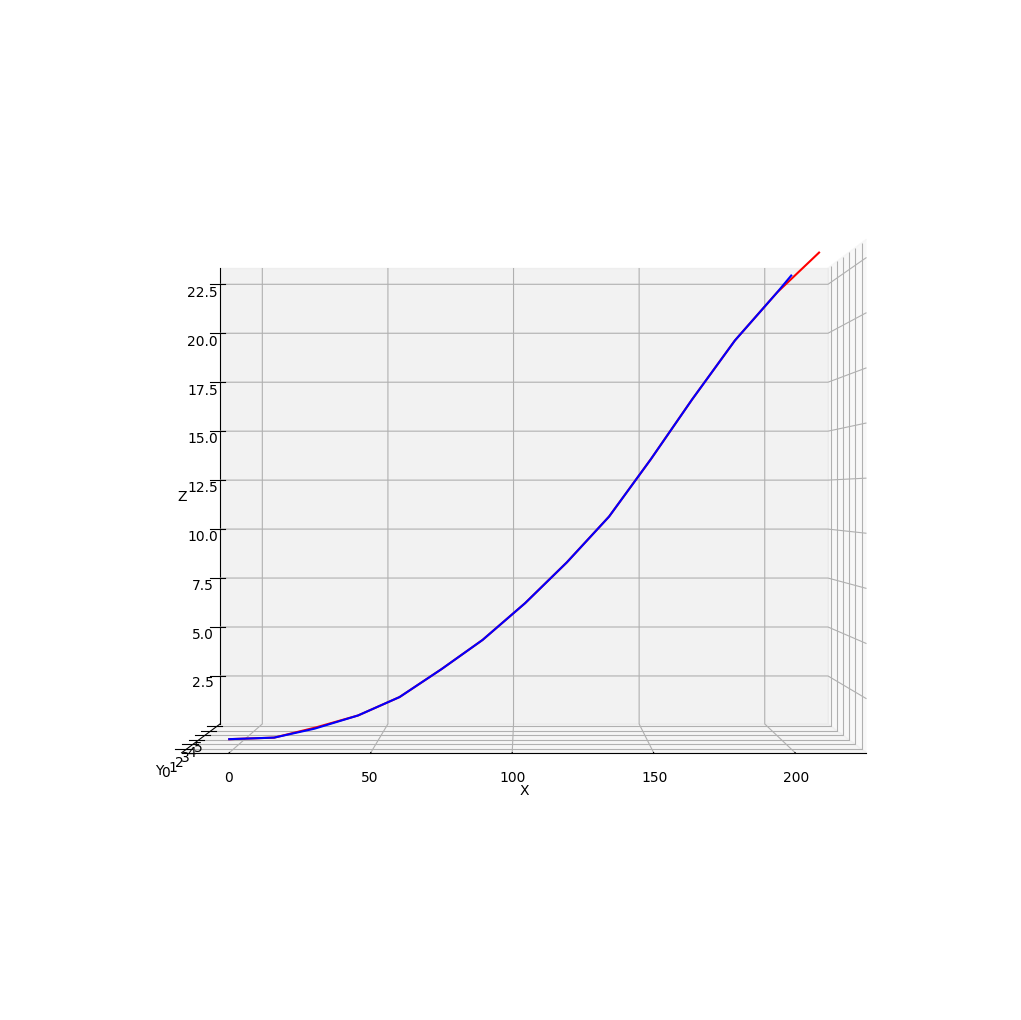

In [91]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
ax.view_init(0,-90)
plt.show()

In [92]:
X,Y,Z

(array([ -1.42464683,  14.69199406,  29.62253879,  44.73532826,
         59.61250239,  74.68310564,  89.34730283, 104.57548394,
        119.5058204 , 134.62859583, 149.6093997 , 164.34078887,
        179.72458822, 194.76803358, 209.78414705]),
 array([ 1.72052567e-09,  5.61817395e-10, -2.71982088e-08, -1.07600898e-09,
        -6.51166753e-10, -2.58174744e-10, -1.31314052e-09,  1.15283588e-08,
         7.25440785e-10, -9.24843504e-10,  2.39179624e-10, -3.79129023e-10,
         9.18398851e-10, -2.41358412e-09,  5.17411783e-07]),
 array([ 0.51489628,  0.58822561,  1.06058306,  1.60869396,  2.45411471,
         3.74090881,  5.08007471,  6.75639933,  8.63965105, 10.74473961,
        13.38181976, 16.11933926, 18.83658821, 21.03577592, 22.86681453]))

In [93]:
X0,Y0,Z0

(array([ -1.42464683,  14.69200351,  29.62254101,  44.73532892,
         59.612504  ,  74.68310666,  89.347305  , 104.57548727,
        119.50582408, 134.62859863, 149.609402  , 164.34079211,
        179.72459316, 194.7680357 , 209.78441957]),
 array([ 1.72052567e-09,  5.62139739e-10, -2.21569745e-09, -1.07595865e-09,
        -8.00078396e-10, -2.58161745e-10, -1.31363916e-09,  1.15283528e-08,
         7.25427712e-10, -9.24841531e-10,  2.39180264e-10, -3.79130665e-10,
         9.18518430e-10, -2.36961320e-09, -2.70738475e-09]),
 array([ 0.51489628,  0.58822501,  1.06058306,  1.60869429,  2.45411475,
         3.74090876,  5.08007531,  6.75640023,  8.63965223, 10.74474004,
        13.38182057, 16.11933999, 18.83658985, 21.03577711, 22.86681065]))

In [94]:
us=fin.T

In [95]:
us.shape

(405, 19363)

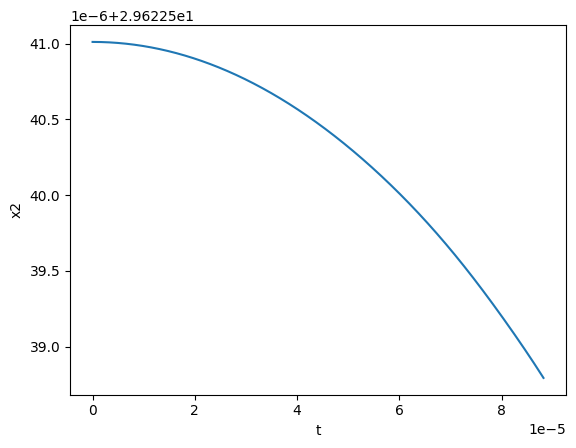

In [96]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

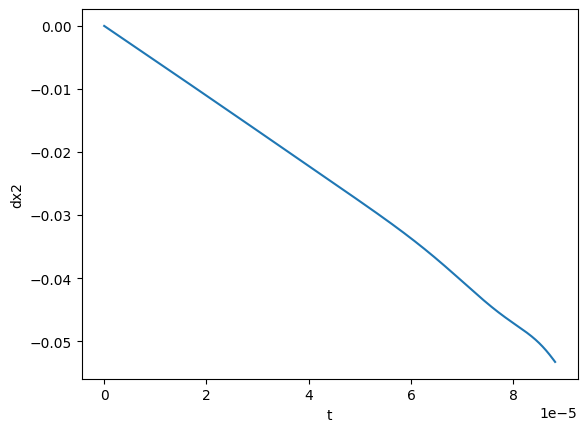

In [97]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

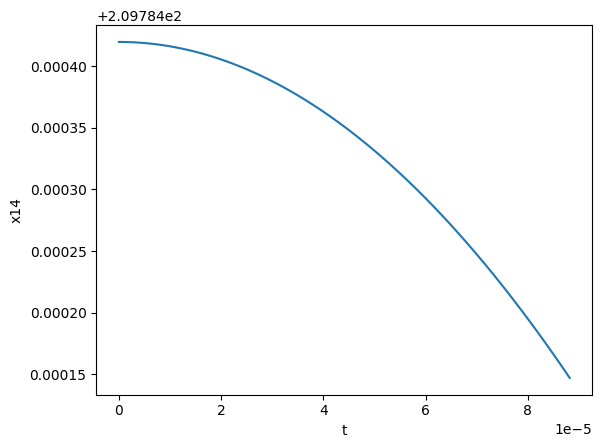

In [98]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

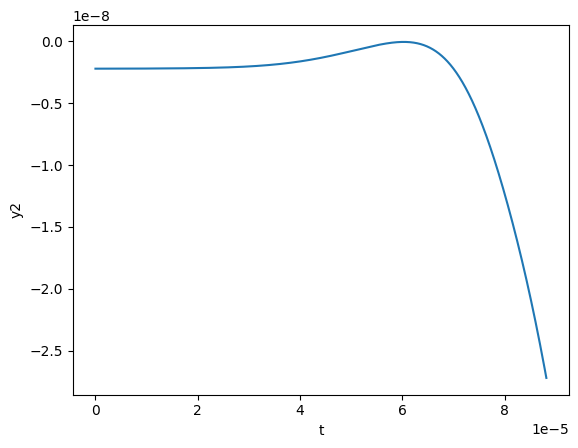

In [99]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

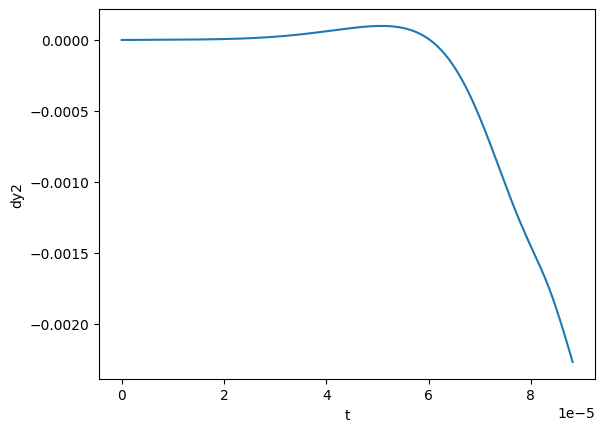

In [100]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

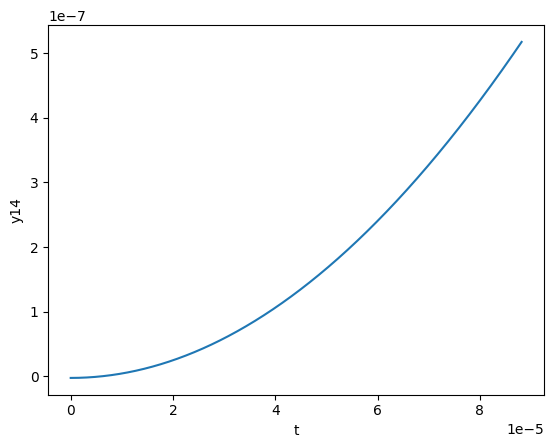

In [101]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

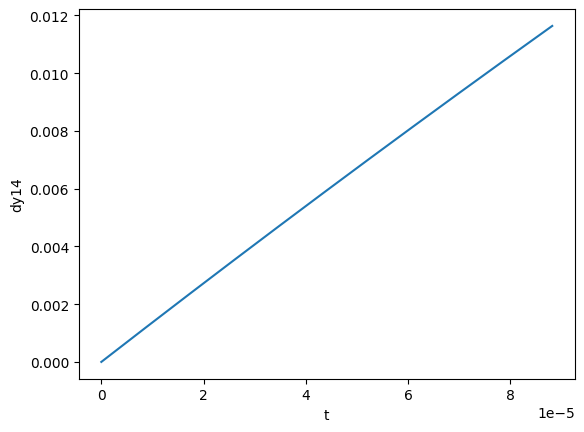

In [102]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

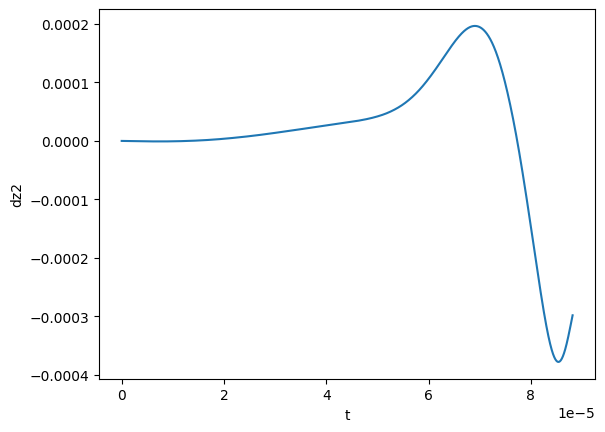

In [103]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

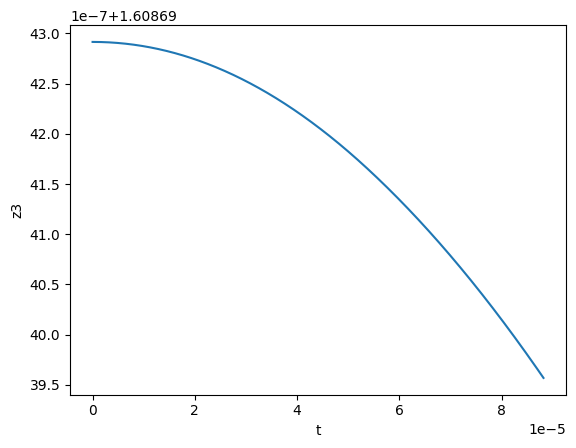

In [104]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

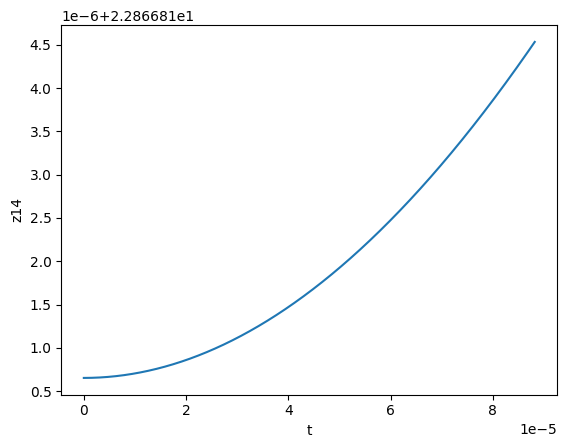

In [105]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

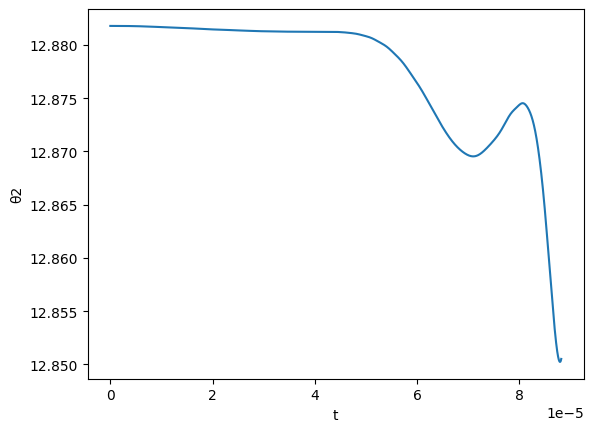

In [106]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

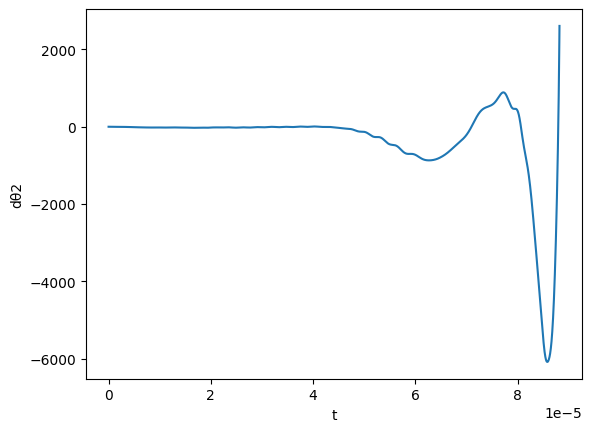

In [107]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

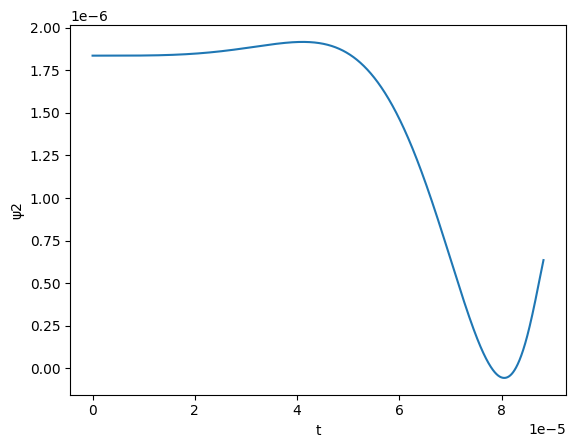

In [108]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

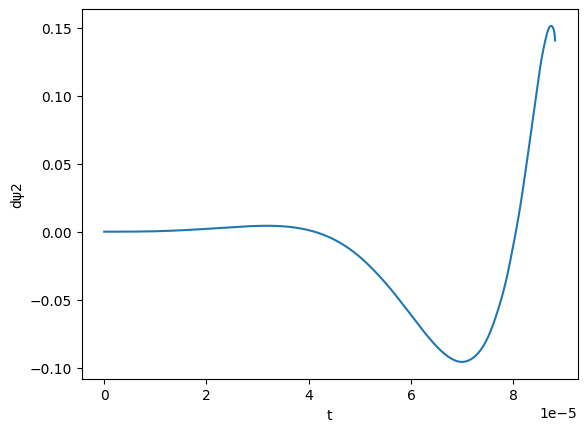

In [109]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

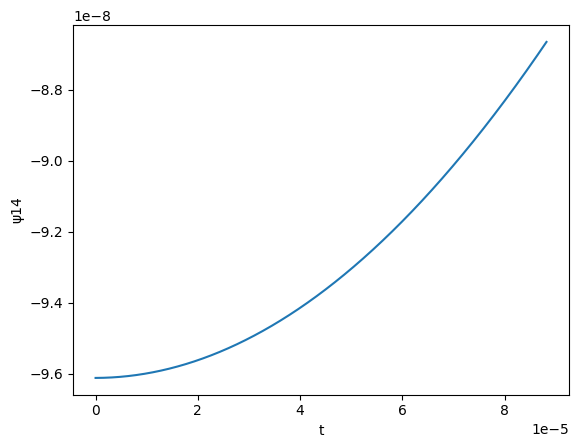

In [110]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [111]:
X010=us.T[:,0*N:1*N]

In [112]:
Y010=us.T[:,2*N:3*N]

In [113]:
Z010=us.T[:,4*N:5*N]

In [114]:
# simulation = np.stack([X010,Y010,Z010],axis=2) 

# FPS = 5                      
# frame_duration = 1000 / FPS

# frames = []
# for t in range(simulation.shape[0]):
#     x = simulation[t,:,0]
#     y = simulation[t,:,1]
#     z = simulation[t,:,2]

#     frames.append(go.Frame(
#         data=[
#             go.Scatter3d(
#                 x=x, y=y, z=z,
#                 mode="lines+markers",
#                 marker=dict(size=5, color=list(range(12)), colorscale="Viridis"),
#                 line=dict(width=4)
#             )
#         ],
#         name=f"t={t}"
#     ))

# # First frame
# x0, y0, z0 = simulation[0,:,0], simulation[0,:,1], simulation[0,:,2]

# fig = go.Figure(
#     data=[go.Scatter3d(x=x0, y=y0, z=z0, mode="lines+markers")],
#     frames=frames
# )

# # Animation controls
# fig.update_layout(
#     title="Pipeline Simulation ",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 400]),
#         yaxis=dict(range=[-50, 50]),
#         zaxis=dict(range=[0, 100]),
#         aspectmode="data",
       
#     ),
#     updatemenus=[{
#         "type": "buttons",
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {"frame": {"duration": frame_duration, "redraw": True}}]
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {"frame": {"duration": 0}}]
#             }
#         ]
#     }]
# )

# fig.show()